In [ ]:
import random
import math
import matplotlib.pyplot as plt

In [ ]:
random.seed(42)  # Fix seed so results are reproducible

def generate_data(n=120):

    data = []
    for i in range(n):
        age            = random.randint(18, 65)
        income         = random.randint(20000, 120000)
        spending_score = random.randint(1, 100)


        score = (income / 120000) * 50 + (spending_score / 100) * 50
        if score > 50 + random.uniform(-10, 10):
            label = 1
        else:
            label = 0

        data.append([age, income, spending_score, label])

    return data

dataset = generate_data(120)

print("Sample rows (age, income, spending_score, label):")
for row in dataset[:5]:
    print(row)

print(f"\nTotal customers: {len(dataset)}")
print(f"Buyers (label=1): {sum(1 for r in dataset if r[3]==1)}")
print(f"Non-buyers (label=0): {sum(1 for r in dataset if r[3]==0)}")

Sample rows (age, income, spending_score, label):
[58, 34592, 4, 0]
[33, 49256, 18, 0]
[61, 117080, 70, 1]
[45, 24165, 4, 0]
[32, 86237, 78, 1]

Total customers: 120
Buyers (label=1): 63
Non-buyers (label=0): 57


In [ ]:
def get_features_and_labels(data):

    X = [row[:3] for row in data]   # [[age, income, spending_score], ...]
    y = [row[3]  for row in data]   # [0, 1, 1, 0, ...]
    return X, y


def min_max_normalize(X):
    num_features = len(X[0])  # 3 features
    mins = []
    maxs = []

    #finding min and max for each feature column
    for col in range(num_features):
        col_values = [row[col] for row in X]
        mins.append(min(col_values))
        maxs.append(max(col_values))

    #now normalize every value
    X_norm = []
    for row in X:
        norm_row = []
        for col in range(num_features):
            denom = maxs[col] - mins[col]
            if denom == 0:
                norm_row.append(0.0)  #avoid divide by zero if all values are the same
            else:
                norm_row.append((row[col] - mins[col]) / denom)
        X_norm.append(norm_row)

    return X_norm, mins, maxs


def normalize_with_params(X, mins, maxs):
    num_features = len(X[0])
    X_norm = []
    for row in X:
        norm_row = []
        for col in range(num_features):
            denom = maxs[col] - mins[col]
            if denom == 0:
                norm_row.append(0.0)
            else:
                norm_row.append((row[col] - mins[col]) / denom)
        X_norm.append(norm_row)
    return X_norm


def train_test_split(X, y, test_ratio=0.2, seed=42):
    random.seed(seed)
    indices = list(range(len(X)))
    random.shuffle(indices)  # shuffle index positions

    split_point = int(len(X) * (1 - test_ratio))

    train_idx = indices[:split_point]
    test_idx  = indices[split_point:]

    X_train = [X[i] for i in train_idx]
    y_train = [y[i] for i in train_idx]
    X_test  = [X[i] for i in test_idx]
    y_test  = [y[i] for i in test_idx]

    return X_train, X_test, y_train, y_test


def euclidean_distance(a, b):
    return math.sqrt(sum((a[i] - b[i])**2 for i in range(len(a))))

In [ ]:
X, y = get_features_and_labels(dataset)
X_norm, mins, maxs = min_max_normalize(X)
X_train, X_test, y_train, y_test = train_test_split(X_norm, y)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"\nFirst normalized training row: {X_train[0]}")

Training samples : 96
Testing  samples : 24

First normalized training row: [0.44680851063829785, 0.13339474711872554, 0.11458333333333333]


K-Means converged after 7 iterations.
Cluster 0: 52 customers
Cluster 1: 30 customers
Cluster 2: 38 customers


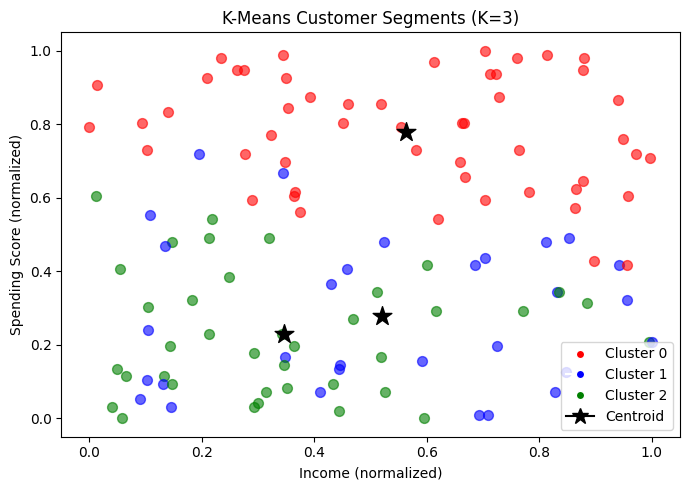

In [ ]:
def kmeans(X, k=3, max_iters=100, seed=42):
    random.seed(seed)
    num_points   = len(X)
    num_features = len(X[0])

    #randomly choosing k data points as starting centroids
    centroid_indices = random.sample(range(num_points), k)
    centroids = [X[i][:] for i in centroid_indices]

    labels = [0] * num_points  #cluster assignment for each point

    for iteration in range(max_iters):

        #assigning each point to the nearest centroid
        new_labels = []
        for point in X:
            distances = [euclidean_distance(point, c) for c in centroids]
            nearest   = distances.index(min(distances))  #index of smallest distance
            new_labels.append(nearest)

        #check for convergence
        if new_labels == labels:
            print(f"K-Means converged after {iteration} iterations.")
            break

        labels = new_labels

        #recomputing each centroid as the mean of its assigned points
        new_centroids = []
        for c in range(k):
            cluster_points = [X[i] for i in range(num_points) if labels[i] == c]

            if len(cluster_points) == 0:
                #edge case: empty cluster = keep old centroid
                new_centroids.append(centroids[c])
            else:
                #mean of each feature dimension
                mean_point = []
                for f in range(num_features):
                    mean_val = sum(p[f] for p in cluster_points) / len(cluster_points)
                    mean_point.append(mean_val)
                new_centroids.append(mean_point)

        centroids = new_centroids

    return labels, centroids

cluster_labels, centroids = kmeans(X_norm, k=3)

#count how many customers are in each cluster
for c in range(3):
    count = cluster_labels.count(c)
    print(f"Cluster {c}: {count} customers")

#visualizing clusters (using features 1=income and 2=spending_score for 2D plot)
colors_map = {0: 'red', 1: 'blue', 2: 'green'}
plt.figure(figsize=(7, 5))
for i, point in enumerate(X_norm):
    plt.scatter(point[1], point[2],
                color=colors_map[cluster_labels[i]],
                alpha=0.6, s=50)

for c in centroids:
    plt.scatter(c[1], c[2], color='black', marker='*', s=200, zorder=5)

plt.xlabel("Income (normalized)")
plt.ylabel("Spending Score (normalized)")
plt.title("K-Means Customer Segments (K=3)")
plt.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='red',   label='Cluster 0'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='blue',  label='Cluster 1'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='green', label='Cluster 2'),
    plt.Line2D([0],[0], marker='*', color='black', label='Centroid', markersize=12),
])
plt.tight_layout()
plt.show()

In [ ]:
def knn_predict(X_train, y_train, X_test, k=5):
    predictions = []

    for test_point in X_test:
        #calculate distance from this test point to every training point
        distances = []
        for i, train_point in enumerate(X_train):
            d = euclidean_distance(test_point, train_point)
            distances.append((d, y_train[i]))  # store (distance, label)

        #sort by distance (smallest first)
        distances.sort(key=lambda x: x[0])

        #taking the K nearest labels
        k_nearest_labels = [distances[j][1] for j in range(k)]

        #Majority vote - which label appears more?
        vote_1 = k_nearest_labels.count(1)
        vote_0 = k_nearest_labels.count(0)
        predicted_label = 1 if vote_1 > vote_0 else 0

        predictions.append(predicted_label)

    return predictions

knn_preds = knn_predict(X_train, y_train, X_test, k=5)

print("KNN Predictions (first 10):", knn_preds[:10])
print("Actual Labels   (first 10):", y_test[:10])

KNN Predictions (first 10): [1, 0, 1, 0, 0, 1, 0, 1, 1, 0]
Actual Labels   (first 10): [1, 0, 1, 1, 0, 1, 0, 1, 1, 0]


In [ ]:
def gini_impurity(labels):

    n = len(labels)
    if n == 0:
        return 0.0
    count_1 = labels.count(1)
    count_0 = labels.count(0)
    p1 = count_1 / n
    p0 = count_0 / n
    return 1 - (p1**2 + p0**2)


def best_split(X, y):
    best_gini      = float('inf')
    best_feature   = None
    best_threshold = None

    num_features = len(X[0])

    for feature in range(num_features):
        #collect all unique values for this feature as candidate thresholds
        values = sorted(set(row[feature] for row in X))

        for threshold in values:
            #split data into left (<= threshold) and right (> threshold)
            y_left  = [y[i] for i in range(len(X)) if X[i][feature] <= threshold]
            y_right = [y[i] for i in range(len(X)) if X[i][feature] >  threshold]

            if len(y_left) == 0 or len(y_right) == 0:
                continue  #skip splits that don't actually divide the data

            #Weighted Gini= weight each side by its proportion of total samples
            n = len(y)
            weighted_gini = (len(y_left)/n)  * gini_impurity(y_left) + \
                            (len(y_right)/n) * gini_impurity(y_right)

            if weighted_gini < best_gini:
                best_gini      = weighted_gini
                best_feature   = feature
                best_threshold = threshold

    return best_feature, best_threshold


def build_tree(X, y, depth=0, max_depth=5, min_samples=2):

    #stopping condition 1- pure node
    if len(set(y)) == 1:
        return {'label': y[0]}

    #stopping condition 2 - max depth or too few samples
    if depth >= max_depth or len(y) < min_samples:
        #return majority label
        majority = 1 if y.count(1) >= y.count(0) else 0
        return {'label': majority}

    #finding the best split
    feature, threshold = best_split(X, y)

    if feature is None:
        #no valid split found = return majority label
        majority = 1 if y.count(1) >= y.count(0) else 0
        return {'label': majority}

    #spliting data into left and right subsets
    left_X,  left_y  = [], []
    right_X, right_y = [], []
    for i in range(len(X)):
        if X[i][feature] <= threshold:
            left_X.append(X[i]);  left_y.append(y[i])
        else:
            right_X.append(X[i]); right_y.append(y[i])

    #recursively build left and right subtrees
    left_subtree  = build_tree(left_X,  left_y,  depth+1, max_depth, min_samples)
    right_subtree = build_tree(right_X, right_y, depth+1, max_depth, min_samples)

    return {
        'feature'  : feature,
        'threshold': threshold,
        'left'     : left_subtree,
        'right'    : right_subtree
    }


def tree_predict_one(tree, sample):
    if 'label' in tree:
        return tree['label']

    # Go left or right depending on the feature value
    if sample[tree['feature']] <= tree['threshold']:
        return tree_predict_one(tree['left'],  sample)
    else:
        return tree_predict_one(tree['right'], sample)


def tree_predict(tree, X_test):

    return [tree_predict_one(tree, sample) for sample in X_test]


dt = build_tree(X_train, y_train, max_depth=5)
dt_preds = tree_predict(dt, X_test)

print("Decision Tree Predictions (first 10):", dt_preds[:10])
print("Actual Labels              (first 10):", y_test[:10])


Decision Tree Predictions (first 10): [1, 0, 1, 0, 0, 1, 0, 1, 1, 0]
Actual Labels              (first 10): [1, 0, 1, 1, 0, 1, 0, 1, 1, 0]


Training ANN...
Epoch 100/500  |  Loss: 0.0645
Epoch 200/500  |  Loss: 0.0625
Epoch 300/500  |  Loss: 0.0620
Epoch 400/500  |  Loss: 0.0615
Epoch 500/500  |  Loss: 0.0601


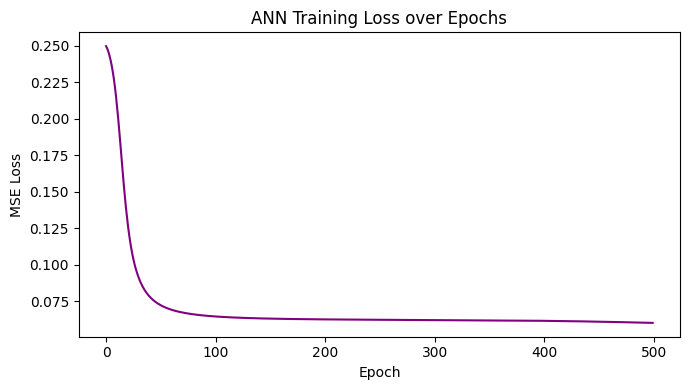

In [ ]:
def sigmoid(x):

    return 1 / (1 + math.exp(-x))

def sigmoid_derivative(x):

    s = sigmoid(x)
    return s * (1 - s)

def dot(a, b):

    return sum(a[i] * b[i] for i in range(len(a)))

def mat_vec_mul(matrix, vector):

    return [dot(row, vector) for row in matrix]


def initialize_weights(input_size, hidden_size, output_size, seed=42):

    random.seed(seed)

    W1 = [[random.uniform(-0.5, 0.5) for _ in range(input_size)]
          for _ in range(hidden_size)]
    b1 = [random.uniform(-0.5, 0.5) for _ in range(hidden_size)]

    W2 = [[random.uniform(-0.5, 0.5) for _ in range(hidden_size)]
          for _ in range(output_size)]
    b2 = [random.uniform(-0.5, 0.5) for _ in range(output_size)]

    return W1, b1, W2, b2


def forward_pass(x, W1, b1, W2, b2):
    # Hidden layer
    z1 = [dot(W1[h], x) + b1[h] for h in range(len(W1))]  # weighted sum + bias
    a1 = [sigmoid(v) for v in z1]                           # apply activation

    # Output layer
    z2 = [dot(W2[o], a1) + b2[o] for o in range(len(W2))]
    a2 = [sigmoid(v) for v in z2]

    return z1, a1, z2, a2


def train_ann(X_train, y_train, hidden_size=4, lr=0.1, epochs=500):

    input_size  = len(X_train[0])  # 3
    output_size = 1

    W1, b1, W2, b2 = initialize_weights(input_size, hidden_size, output_size)

    loss_history = []

    for epoch in range(epochs):
        total_loss = 0.0

        for i in range(len(X_train)):
            x      = X_train[i]
            y_true = y_train[i]

            #FORWARD PASS
            z1, a1, z2, a2 = forward_pass(x, W1, b1, W2, b2)
            y_pred = a2[0]  # single output neuron

            #mean Squared Error loss for this sample
            loss = (y_pred - y_true) ** 2
            total_loss += loss

            #BACKWARD PASS
            #Gradient of loss wrt output activation
            # d_loss/d_a2 = 2*(y_pred - y_true)
            d_loss_a2 = 2 * (y_pred - y_true)

            #gradient through sigmoid at output layer
            # d_a2/d_z2 = sigmoid'(z2)
            d_a2_z2 = sigmoid_derivative(z2[0])

            #how much loss changes wrt z2
            delta2 = d_loss_a2 * d_a2_z2  # scalar

            # Gradients for W2 and b2
            # d_loss/d_W2[o][h] = delta2 * a1[h]
            grad_W2 = [[delta2 * a1[h] for h in range(hidden_size)]]
            grad_b2 = [delta2]

            # Backpropagate error to hidden layer
            # delta1[h] = (sum over outputs of delta2 * W2[o][h]) * sigmoid'(z1[h])
            delta1 = []
            for h in range(hidden_size):
                error_h = sum(delta2 * W2[o][h] for o in range(output_size))
                delta1.append(error_h * sigmoid_derivative(z1[h]))

            #Gradients for W1 and b1
            grad_W1 = [[delta1[h] * x[f]
                        for f in range(input_size)]
                       for h in range(hidden_size)]
            grad_b1 = delta1[:]

            #WEIGHT UPDATE (Gradient Descent)
            # W = W - learning_rate * gradient
            for h in range(hidden_size):
                for f in range(input_size):
                    W1[h][f] -= lr * grad_W1[h][f]
                b1[h] -= lr * grad_b1[h]

            for o in range(output_size):
                for h in range(hidden_size):
                    W2[o][h] -= lr * grad_W2[o][h]
                b2[o] -= lr * grad_b2[o]

        #avg loss for this epoch
        avg_loss = total_loss / len(X_train)
        loss_history.append(avg_loss)

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs}  |  Loss: {avg_loss:.4f}")

    return W1, b1, W2, b2, loss_history


def ann_predict(X_test, W1, b1, W2, b2, threshold=0.5):
    predictions = []
    for x in X_test:
        _, _, _, a2 = forward_pass(x, W1, b1, W2, b2)
        pred = 1 if a2[0] >= threshold else 0
        predictions.append(pred)
    return predictions

print("Training ANN...")
W1, b1, W2, b2, loss_history = train_ann(X_train, y_train,
                                          hidden_size=4, lr=0.1, epochs=500)

ann_preds = ann_predict(X_test, W1, b1, W2, b2)

plt.figure(figsize=(7, 4))
plt.plot(loss_history, color='purple')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("ANN Training Loss over Epochs")
plt.tight_layout()
plt.show()


In [ ]:

def confusion_matrix(y_true, y_pred):
    TP = sum(1 for a, p in zip(y_true, y_pred) if a == 1 and p == 1)
    TN = sum(1 for a, p in zip(y_true, y_pred) if a == 0 and p == 0)
    FP = sum(1 for a, p in zip(y_true, y_pred) if a == 0 and p == 1)
    FN = sum(1 for a, p in zip(y_true, y_pred) if a == 1 and p == 0)
    return TP, TN, FP, FN


def compute_metrics(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix(y_true, y_pred)

    accuracy  = (TP + TN) / len(y_true) if len(y_true) > 0 else 0

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0

    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0)

    return {
        'Accuracy' : round(accuracy,  4),
        'Precision': round(precision, 4),
        'Recall'   : round(recall,    4),
        'F1 Score' : round(f1,        4),
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN
    }


#evaluating all three models
models = {
    'KNN'          : knn_preds,
    'Decision Tree': dt_preds,
    'ANN'          : ann_preds,
}

results = {}
print("=" * 55)
print(f"{'Model':<16} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("=" * 55)
for name, preds in models.items():
    m = compute_metrics(y_test, preds)
    results[name] = m
    print(f"{name:<16} {m['Accuracy']:>9.4f} {m['Precision']:>10.4f} "
          f"{m['Recall']:>8.4f} {m['F1 Score']:>8.4f}")
print("=" * 55)

#confusion matrix for each model
for name, preds in models.items():
    m = results[name]
    print(f"\n{name} Confusion Matrix:")
    print(f"  Predicted →     0       1")
    print(f"  Actual 0  |  TN={m['TN']:3}   FP={m['FP']:3}")
    print(f"  Actual 1  |  FN={m['FN']:3}   TP={m['TP']:3}")


Model             Accuracy  Precision   Recall       F1
KNN                 0.8750     0.9167   0.8462   0.8800
Decision Tree       0.9167     0.9231   0.9231   0.9231
ANN                 0.9167     0.9231   0.9231   0.9231

KNN Confusion Matrix:
  Predicted →     0       1
  Actual 0  |  TN= 10   FP=  1
  Actual 1  |  FN=  2   TP= 11

Decision Tree Confusion Matrix:
  Predicted →     0       1
  Actual 0  |  TN= 10   FP=  1
  Actual 1  |  FN=  1   TP= 12

ANN Confusion Matrix:
  Predicted →     0       1
  Actual 0  |  TN= 10   FP=  1
  Actual 1  |  FN=  1   TP= 12


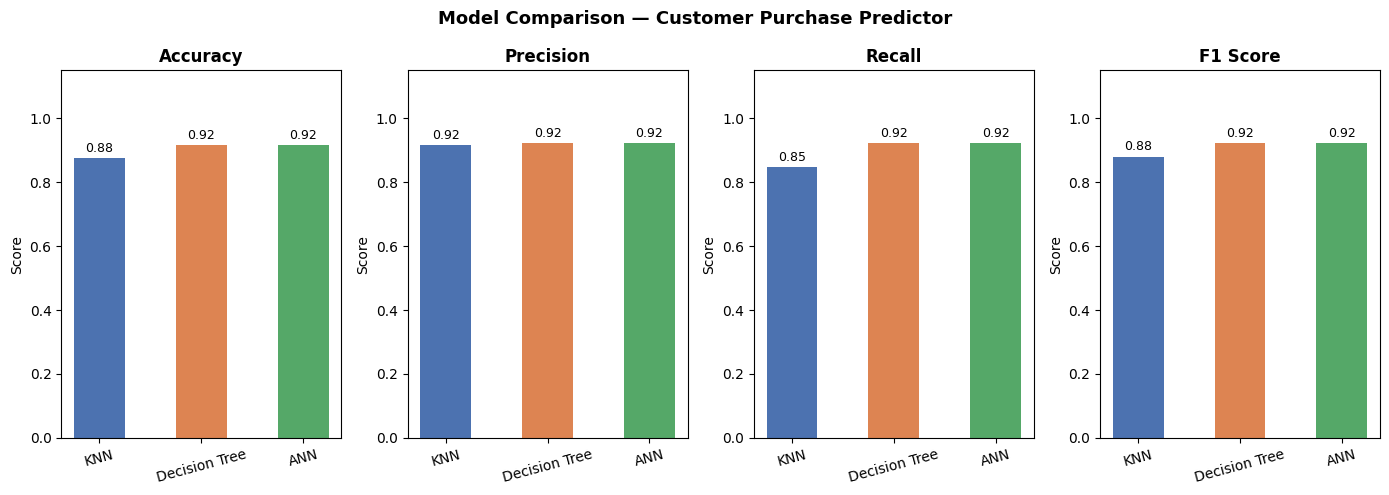

In [ ]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names   = list(results.keys())

#prep data = one list per metric
metric_data = {m: [results[model][m] for model in model_names]
               for m in metrics_names}

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric in zip(axes, metrics_names):
    values = metric_data[metric]
    bars   = ax.bar(model_names, values, color=colors, width=0.5)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.2f}",
                ha='center', va='bottom', fontsize=9)

    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.tick_params(axis='x', rotation=15)

plt.suptitle("Model Comparison — Customer Purchase Predictor", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
